In [148]:
import pandas as pd
import numpy as np
import time

from sklearn.cluster import DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors

In [ ]:
df = pd.read_csv("../../data/processed/clean_dataset.csv")
X = df.values
feature_names = df.columns
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,7/29/2023 13:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,13,7,7
1,8/13/2023 0:11,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,2,0,1,8
2,12/9/2021 10:30,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,10,5,12
3,8/9/2023 19:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5,0,0,5,0,0,19,4,8
4,8/19/2023 14:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,14,7,8


In [150]:
df['most_severe_injury'].unique()

array(['NO INDICATION OF INJURY', 'NONINCAPACITATING INJURY',
       'INCAPACITATING INJURY', 'REPORTED, NOT EVIDENT', 'FATAL'],
      dtype=object)

In [151]:
def map_injury(x):
    if x in ['NO INDICATION OF INJURY', 'REPORTED, NOT EVIDENT']:
        return 'LOW'
    else:
        return 'HIGH'

df['injury_level'] = df['most_severe_injury'].apply(map_injury)
print(df['injury_level'].value_counts())

injury_level
LOW     170840
HIGH     38435
Name: count, dtype: int64


In [152]:
df_low = df[df['injury_level'] == 'LOW']
df_high = df[df['injury_level'] == 'HIGH']

In [153]:
def stratified_sample(df, group_cols, n_total=5000, min_per_group=50, random_state=52):
    df = df.dropna(subset=group_cols)

    # Size & tỷ lệ
    group_sizes = df.groupby(group_cols).size()
    proportions = group_sizes / group_sizes.sum()

    # Sample theo tỷ lệ
    sample_sizes = (proportions * n_total).round().astype(int)

    sampled_df = []

    for group, size in sample_sizes.items():
        group_df = df.copy()

        # lọc group
        for col, val in zip(group_cols, group if isinstance(group, tuple) else (group,)):
            group_df = group_df[group_df[col] == val]

        if len(group_df) == 0:
            continue

        # Đảm bảo không quá nhỏ
        size = max(size, min_per_group)

        # Không vượt quá dữ liệu thật
        size = min(size, len(group_df))

        sampled_df.append(
            group_df.sample(n=size, random_state=random_state)
        )

    return pd.concat(sampled_df).reset_index(drop=True)

In [154]:
df_low = stratified_sample(df_low, ['weather_condition', 'lighting_condition'])
df_high = stratified_sample(df_high, ['weather_condition', 'lighting_condition'])

In [ ]:
features = [
    'weather_condition',        #Thời tiết
    'lighting_condition',       #Ánh sáng
    'roadway_surface_cond',     #Mặt đường
    'trafficway_type',          #Loại đường
    #'alignment',                #Hình dạng đường (thẳng, cong)
    'road_defect',              #Tình trạng đường (ổ gà, trơn trượt) 
    'first_crash_type',         #Loại va chạm đầu tiên (đâm vào, lật xe)
    'prim_contributory_cause',  #Nguyên nhân chính
    'num_units',                #Số lượng phương tiện liên quan
    'crash_hour',               #Giờ xảy ra tai nạn
    'crash_day_of_week',        #Ngày trong tuần (thứ 2, thứ 3, ...)
    # 'intersection_related_i',   #Có liên quan giao lộ hay không
    'traffic_control_device'    #Thiết bị điều khiển giao thông (đèn đỏ, biển báo)
]
num_cols = [
    'num_units',
    'crash_hour',
    'crash_day_of_week'
]

In [156]:
from sklearn.preprocessing import MinMaxScaler
def preprocess_gower(df, features, num_cols):
    df = df[features].dropna().copy()
    
    scaler = MinMaxScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

    return df

In [157]:
import gower

def compute_gower(df):
    return gower.gower_matrix(df)

In [158]:
def plot_k_distance_gower(gower_dist, k=5, title="k-distance"):
    distances = np.sort(gower_dist, axis=1)[:, k]

    k_dist = np.sort(distances)

    plt.figure(figsize=(6,4))
    plt.plot(k_dist)
    plt.title(title)
    plt.xlabel("Points sorted")
    plt.ylabel(f"{k}-NN distance")
    plt.show()

In [159]:
def run_dbscan_gower(gower_dist, eps, min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    labels = model.fit_predict(gower_dist)
    return labels

In [160]:
def evaluate_dbscan_gower(gower_dist, labels):
    mask = labels != -1

    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels)

    if len(set(labels[mask])) < 2:
        return None, None, noise_ratio

    sil = silhouette_score(gower_dist[mask][:, mask], labels[mask], metric='precomputed')
    dbi = davies_bouldin_score(gower_dist[mask][:, mask], labels[mask])

    return sil, dbi, noise_ratio

In [161]:
from sklearn.decomposition import PCA
def visualize_dbscan(df, labels, title="DBSCAN"):
    
    df_temp = pd.get_dummies(df)

    X = df_temp.values

    X_pca = PCA(n_components=2).fit_transform(X)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='tab10', s=15)
    plt.title(f"{title} - DBSCAN")

    plt.tight_layout()
    plt.show()

In [162]:
def profile_clusters(df, labels, features, num_cols):
    df_model = df.copy()
    df_model['cluster'] = labels

    df_model = df_model[df_model['cluster'] != -1]  # Bỏ noise

    def mode_func(x):
        return x.mode().iloc[0] if not x.mode().empty else None

    cat_cols = [c for c in features if c not in num_cols]

    cat_profile = df_model.groupby('cluster')[cat_cols].agg(mode_func)
    num_profile = df_model.groupby('cluster')[num_cols].agg(['mean','median'])

    return cat_profile, num_profile

In [163]:
def find_best_eps(gower_dist, eps_range, min_samples=5):
    results = []

    for eps in eps_range:
        model = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
        labels = model.fit_predict(gower_dist)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.sum(labels == -1) / len(labels)

        # Bỏ case xấu
        if n_clusters < 2:
            results.append({
                "eps": eps,
                "clusters": n_clusters,
                "silhouette": None,
                "dbi": None,
                "noise_ratio": noise_ratio
            })
            continue

        mask = labels != -1

        sil = silhouette_score(
            gower_dist[mask][:, mask],
            labels[mask],
            metric='precomputed'
        )

        dbi = davies_bouldin_score(
            gower_dist[mask][:, mask],
            labels[mask]
        )

        results.append({
            "eps": eps,
            "clusters": n_clusters,
            "silhouette": sil,
            "dbi": dbi,
            "noise_ratio": noise_ratio
        })

    df_results = pd.DataFrame(results)

    return df_results

In [164]:
def select_best_eps(df_results):
    df_valid = df_results.dropna()

    if df_valid.empty:
        print("⚠️ Không tìm được eps phù hợp")
        return None

    df_valid['score'] = (
        df_valid['silhouette'] -
        df_valid['dbi'] -
        df_valid['noise_ratio']
    )

    best_row = df_valid.loc[df_valid['score'].idxmax()]

    return best_row

In [165]:
def plot_eps_metrics(df_results, title="DBSCAN eps tuning"):
    plt.figure(figsize=(15,4))

    # Silhouette
    plt.subplot(1,3,1)
    plt.plot(df_results['eps'], df_results['silhouette'], marker='o')
    plt.title("Silhouette")

    # DBI
    plt.subplot(1,3,2)
    plt.plot(df_results['eps'], df_results['dbi'], marker='o')
    plt.title("DBI")

    # Noise
    plt.subplot(1,3,3)
    plt.plot(df_results['eps'], df_results['noise_ratio'], marker='o')
    plt.title("Noise ratio")

    plt.tight_layout()
    plt.show()

In [166]:

def run_dbscan_pipeline(df, name="LOW"):
    print(f"\n===== {name} - DBSCAN =====")

    # 1. Sampling
    df_sample = stratified_sample(
        df,
        ['weather_condition','lighting_condition']
    )

    # 2. Preprocess
    df_clean = preprocess_gower(df_sample, features, num_cols)

    # 3. Gower
    print("Computing Gower distance...")
    gower_dist = compute_gower(df_clean)

    # 4. K-distance
    print("\n=== K-Distance Graph ===")
    plot_k_distance_gower(gower_dist, k=5, title=f"{name}")

    eps_range = np.linspace(0.1, 0.6, 10)

    df_eps = find_best_eps(gower_dist, eps_range)

    display(df_eps)

    plot_eps_metrics(df_eps, title=f"{name} - eps tuning")

    best = select_best_eps(df_eps)

    if best is None:
        print("Không tìm được eps")
        return

    eps = best['eps']
    print(f"\nBest eps = {eps}")
    min_samples = 5

    # 5. DBSCAN
    start = time.time()
    labels = run_dbscan_gower(gower_dist, eps, min_samples)
    runtime = time.time() - start
    print(f"DBSCAN time: {runtime:.2f} seconds")

    # 6. Evaluation
    sil, dbi, noise_ratio = evaluate_dbscan_gower(gower_dist, labels)

    print("\nEvaluation:")
    print("Silhouette:", sil)
    print("DBI:", dbi)
    print("Noise ratio:", noise_ratio)

    # 7. Cluster size
    print("\nCluster size:")
    print(pd.Series(labels).value_counts())

    # 8. Visualization
    visualize_dbscan(df_clean, labels, title=name)

    # 9. Profile
    if noise_ratio < 0.9:
        cat_profile, num_profile = profile_clusters(df_clean, labels, features, num_cols)

        print("\nCategorical profile:")
        display(cat_profile)

        print("\nNumeric profile:")
        display(num_profile)

        print(f"\n=== {name} - INTERPRETATION ===")

        for c in cat_profile.index:
            print(f"\n--- Cluster {c} ---")

            print("\n[Categorical]")
            print(cat_profile.loc[c].to_string())

            print("\n[Numeric]")
            print(num_profile.loc[c].to_string())
    else:
        print("⚠️ Quá nhiều noise → DBSCAN không phù hợp")


===== LOW - DBSCAN =====
Computing Gower distance...

=== K-Distance Graph ===


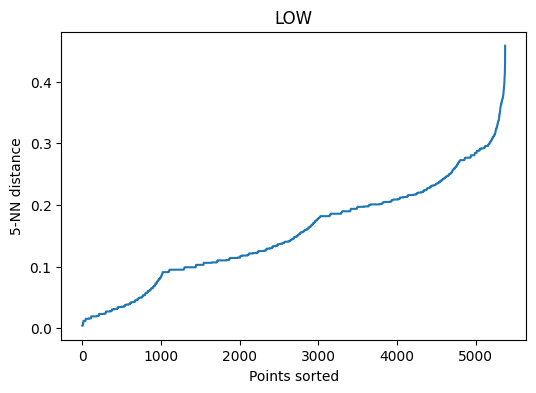

,eps,clusters,silhouette,dbi,noise_ratio
0,0.100000,15,-0.093727,1.012852,0.595424
1,0.155556,9,-0.028394,1.092010,0.324963
2,0.211111,3,0.162613,0.956986,0.097656
3,0.266667,1,NaN,NaN,0.033668
4,0.322222,1,NaN,NaN,0.005022
5,0.377778,1,NaN,NaN,0.000558
6,0.433333,1,NaN,NaN,0.000000
7,0.488889,1,NaN,NaN,0.000000
8,0.544444,1,NaN,NaN,0.000000
9,0.600000,1,NaN,NaN,0.000000


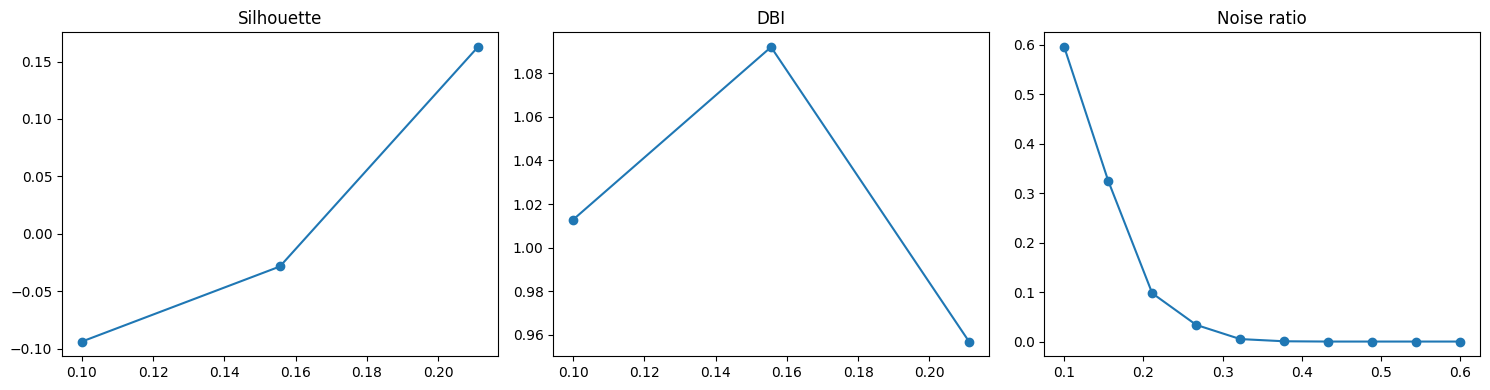

C:\Users\Acer\AppData\Local\Temp\ipykernel_4496\1880622315.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['score'] = (



Best eps = 0.2111111111111111
DBSCAN time: 0.35 seconds

Evaluation:
Silhouette: 0.1626134067773819
DBI: 0.9569860653034409
Noise ratio: 0.09765625

Cluster size:
 0    4843
-1     525
 1       4
 2       4
Name: count, dtype: int64


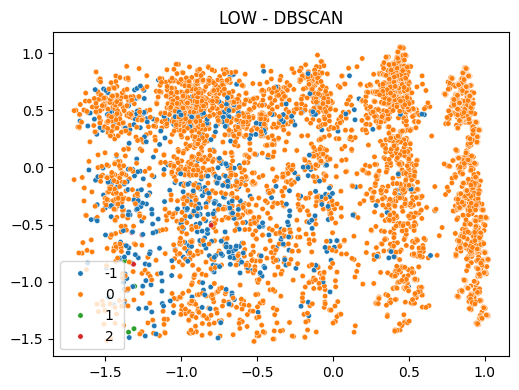


Categorical profile:


,weather_condition,lighting_condition,roadway_surface_cond,trafficway_type,road_defect,first_crash_type,prim_contributory_cause,traffic_control_device
cluster,,,,,,,,
0,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,NO DEFECTS,TURNING,UNKNOWN,TRAFFIC SIGNAL
1,OTHER,DARKNESS,WET,NOT DIVIDED,UNKNOWN,ANGLE,FAILING TO YIELD RIGHT-OF-WAY,STOP SIGN/FLASHER
2,SNOW,UNKNOWN,SNOW OR SLUSH,ONE-WAY,UNKNOWN,REAR END,UNKNOWN,STOP SIGN/FLASHER



Numeric profile:


num_units        crash_hour           crash_day_of_week       
             mean median       mean    median              mean median
cluster                                                               
0        0.211068    0.2   0.583002  0.608696          0.525638   0.50
1        0.250000    0.2   0.673913  0.804348          0.250000   0.25
2        0.200000    0.2   0.630435  0.652174          0.833333   1.00


=== LOW - INTERPRETATION ===

--- Cluster 0 ---

[Categorical]
weather_condition                   CLEAR
lighting_condition               DAYLIGHT
roadway_surface_cond                  DRY
trafficway_type               NOT DIVIDED
road_defect                    NO DEFECTS
first_crash_type                  TURNING
prim_contributory_cause           UNKNOWN
traffic_control_device     TRAFFIC SIGNAL

[Numeric]
num_units          mean      0.211068
                   median    0.200000
crash_hour         mean      0.583002
                   median    0.608696
crash_day_of_week  mean      0.525638
                   median    0.500000

--- Cluster 1 ---

[Categorical]
weather_condition                                  OTHER
lighting_condition                              DARKNESS
roadway_surface_cond                                 WET
trafficway_type                              NOT DIVIDED
road_defect                                      UNKNOWN
first_crash_type                          

In [167]:
run_dbscan_pipeline(df_low, "LOW")


===== HIGH - DBSCAN =====
Computing Gower distance...

=== K-Distance Graph ===


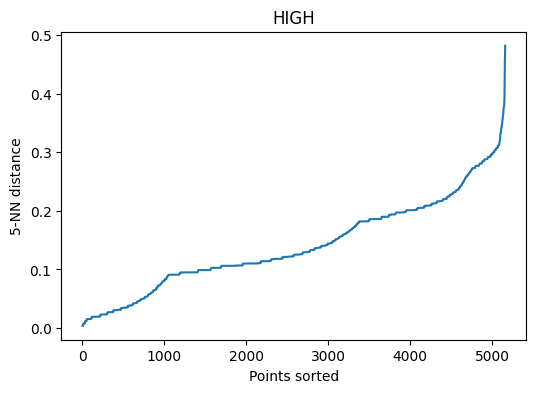

,eps,clusters,silhouette,dbi,noise_ratio
0,0.100000,14,-0.136822,1.006967,0.526550
1,0.155556,6,0.069885,1.016864,0.235465
2,0.211111,1,NaN,NaN,0.069767
3,0.266667,1,NaN,NaN,0.026357
4,0.322222,1,NaN,NaN,0.003101
5,0.377778,1,NaN,NaN,0.000969
6,0.433333,1,NaN,NaN,0.000194
7,0.488889,1,NaN,NaN,0.000000
8,0.544444,1,NaN,NaN,0.000000
9,0.600000,1,NaN,NaN,0.000000


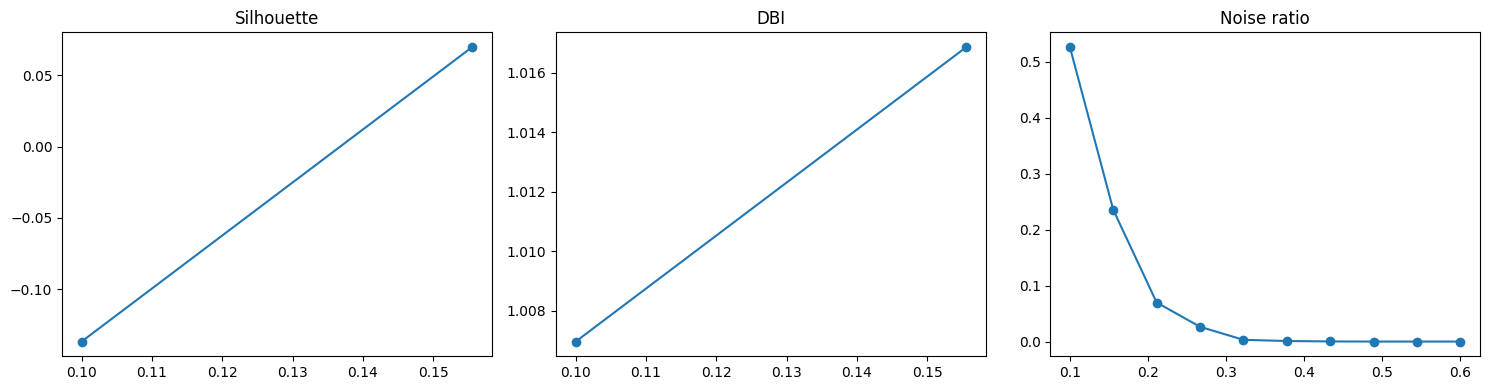

C:\Users\Acer\AppData\Local\Temp\ipykernel_4496\1880622315.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['score'] = (



Best eps = 0.15555555555555556
DBSCAN time: 0.42 seconds

Evaluation:
Silhouette: 0.06988519430160522
DBI: 1.0168638864836508
Noise ratio: 0.23546511627906977

Cluster size:
 0    3922
-1    1215
 5       7
 1       5
 4       5
 2       3
 3       3
Name: count, dtype: int64


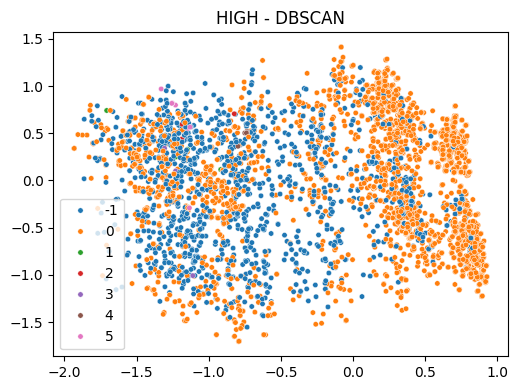


Categorical profile:


,weather_condition,lighting_condition,roadway_surface_cond,trafficway_type,road_defect,first_crash_type,prim_contributory_cause,traffic_control_device
cluster,,,,,,,,
0,CLEAR,DAYLIGHT,DRY,NOT DIVIDED,NO DEFECTS,ANGLE,FAILING TO YIELD RIGHT-OF-WAY,TRAFFIC SIGNAL
1,FREEZING RAIN/DRIZZLE,DAYLIGHT,WET,FOUR WAY,UNKNOWN,PEDESTRIAN,UNKNOWN,TRAFFIC SIGNAL
2,SNOW,DARKNESS,WET,FOUR WAY,NO DEFECTS,TURNING,DISREGARDING TRAFFIC SIGNALS,TRAFFIC SIGNAL
3,SNOW,DAWN,WET,FOUR WAY,NO DEFECTS,PEDESTRIAN,FAILING TO YIELD RIGHT-OF-WAY,TRAFFIC SIGNAL
4,SNOW,DUSK,SNOW OR SLUSH,FOUR WAY,NO DEFECTS,ANGLE,DISREGARDING TRAFFIC SIGNALS,TRAFFIC SIGNAL
5,UNKNOWN,"DARKNESS, LIGHTED ROAD",UNKNOWN,FOUR WAY,UNKNOWN,ANGLE,UNKNOWN,TRAFFIC SIGNAL



Numeric profile:


num_units        crash_hour           crash_day_of_week          
             mean median       mean    median              mean    median
cluster                                                                  
0        0.141382  0.125   0.580327  0.608696          0.519548  0.500000
1        0.125000  0.125   0.591304  0.565217          0.600000  0.666667
2        0.125000  0.125   0.840580  0.826087          0.666667  0.833333
3        0.125000  0.125   0.275362  0.260870          0.833333  0.833333
4        0.125000  0.125   0.513043  0.695652          0.300000  0.166667
5        0.125000  0.125   0.329193  0.217391          0.238095  0.166667


=== HIGH - INTERPRETATION ===

--- Cluster 0 ---

[Categorical]
weather_condition                                  CLEAR
lighting_condition                              DAYLIGHT
roadway_surface_cond                                 DRY
trafficway_type                              NOT DIVIDED
road_defect                                   NO DEFECTS
first_crash_type                                   ANGLE
prim_contributory_cause    FAILING TO YIELD RIGHT-OF-WAY
traffic_control_device                    TRAFFIC SIGNAL

[Numeric]
num_units          mean      0.141382
                   median    0.125000
crash_hour         mean      0.580327
                   median    0.608696
crash_day_of_week  mean      0.519548
                   median    0.500000

--- Cluster 1 ---

[Categorical]
weather_condition          FREEZING RAIN/DRIZZLE
lighting_condition                      DAYLIGHT
roadway_surface_cond                         WET
trafficway_type                         FOUR WAY
road_defec

In [168]:
run_dbscan_pipeline(df_high, "HIGH")